In [1]:
from hess_ml.src.Observables import Observables
import os 
import numpy as np 
import pickle as pickle
import matplotlib.pyplot as plt
import tomli 

In [10]:
from operator import matmul 

def coord_rot(coord_var,rotM):
    for i in range(len(coord_var.iloc[:,1])):
        coord_var.iloc[i,1:] = matmul(rotM,coord_var.iloc[i,1:])
    return coord_var

class TEST(Observables):
    def __init__(self,pwd) -> None:
        super().__init__()
        self.pwd = pwd
        return 

    def comp_test_observables(self):
        print('Computing Observables ...',end="")
        self.freq_pred_list = []      
        self.ZPE_pred = []
        self.Z_pred = []

        self.freq_true_list = []
        self.ZPE_true  = []
        self.Z_true  = []

        with open(f'{self.pwd}/pred_structures_final.json','rb') as f:
            i = 0 
            while True:
                i +=1 
                try:
                    temp_obj = pickle.load(f)
                    self.dir = temp_obj.get('dir')

                    self.R_MI_APF_mat = temp_obj.get('R_MI_APF_mat')

                    self.init_R_MI_mat = temp_obj.get('init_R_MI')

                    self.xyz = temp_obj.get('xyz')

                    #self.xyz = coord_rot(self.xyz,(self.init_R_MI_mat))

                    self.transpose_list = temp_obj.get('transpose_list')
                    self.N_atoms = temp_obj.get('N_atoms')

                    self.lamb_len = temp_obj.get('lamb_len')

                    hess_vec_ab = np.array(temp_obj.get('pred_target_AB'))
                    hess_vec_aa = None

                    hessian_dftdt4 = temp_obj.get('hessian_dftd4')

                    freq = self.gen_Frequencies(hess_vec_aa,hess_vec_ab,hess_d4=hessian_dftdt4,pred=True)
                    freq_pred= freq
                    ZPE = self.get_ZPE(freq)
                    Z = self.get_partition_func(np.sort(np.abs(freq))[6:])

                    #ZPE_harm = self.get_harmonic_ZPE(freq)
                    self.Z_pred.append(Z)
                    #ZPE_harm_pred.append(ZPE_harm)
                    self.ZPE_pred.append(ZPE)

                    self.freq_pred_list.extend(freq)
                    
                    S_pred =   np.log(Z)*8.314*0.2390057

                    hess_vec_aa = np.array(temp_obj.get('Target_AA'))
                    hess_vec_ab = np.array(temp_obj.get('Target_AB'))

                    freq = self.gen_Frequencies(hess_vec_aa,hess_vec_ab,hess_d4=hessian_dftdt4,pred=False)
                    ZPE = self.get_ZPE(freq)
                    Z = self.get_partition_func(np.sort(np.abs(freq))[6:])

                    S_true =   np.log(Z)*8.314*0.2390057

                    if np.abs(S_true - S_pred) > 1.5:
                        print(self.dir)
                        print('True',freq)
                        print('Prediction',freq_pred)
                        
                    #ZPE_harm = self.get_harmonic_ZPE(freq)
                    self.Z_true.append(Z)

                    #ZPE_harm_true.append(ZPE_harm)
                    self.ZPE_true.append(ZPE)
                    self.freq_true_list.extend(freq)

                  

                except EOFError:
                        break     
                   
        self.freq_pred_list = np.array(self.freq_pred_list)
        self.freq_true_list = np.array(self.freq_true_list)

        self.Z_pred = np.array(self.Z_pred)
        self.Z_true = np.array(self.Z_true)

        self.ZPE_pred = np.array(self.ZPE_pred)
        self.ZPE_true = np.array(self.ZPE_true)
        print('done')

        return

In [11]:
print(os.path.realpath('test.ipynb'))

a = TEST('/Users/gfeldmann/Documents/hessian/gdb7/gdb7_pred_best/')

a.comp_test_observables()

/Users/gfeldmann/Documents/GitLab/hessian_ml/test.ipynb
Computing Observables ...done


In [31]:
print(0.0006709*219474.63,0.00014694*219474.63)


147.245529267 32.2496021322


Text(2574.774704856947, 495.5484394671105, 'RMSD: 13.892')

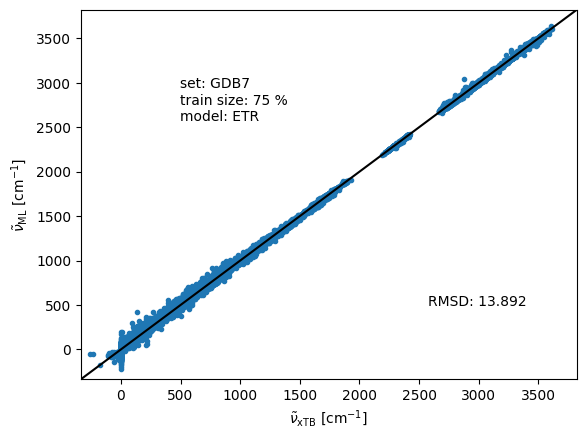

In [5]:
freq_pred =   a.freq_pred_list*219474.63
freq_true =   a.freq_true_list*219474.63

minv,maxv = np.min([np.min(freq_true),np.min(freq_pred)])*1.3,np.max([np.max(freq_true),np.max(freq_pred)])*1.05

plt.plot(freq_true,freq_pred,'.')
plt.plot([minv-np.abs(minv),2*maxv],[minv-np.abs(minv),2*maxv],'k')

RMSD = np.sqrt(np.sum((freq_true-freq_pred)**2)/len(freq_pred))

plt.xlabel(r'$\tilde{\nu}$$_\mathrm{xTB}$ [cm$^{-1}$]')
plt.ylabel(r'$\tilde{\nu}$$_\mathrm{ML}$ [cm$^{-1}$]')

plt.xlim([minv,maxv])
plt.ylim([minv,maxv])

plt.text((maxv-minv)*0.2+minv,(maxv-minv)*0.7+minv,f'set: GDB7 \ntrain size: 75 %\nmodel: ETR')
plt.text((maxv-minv)*0.7+minv,(maxv-minv)*0.2+minv,f'RMSD: {round(RMSD,3)}')
#plt.savefig('/Users/gfeldmann/Documents/hessian/gdb7/gdb7_pred_best/Frequencies.svg')

Text(105.03001422549883, 48.0874041741838, 'RMSD: 0.195')

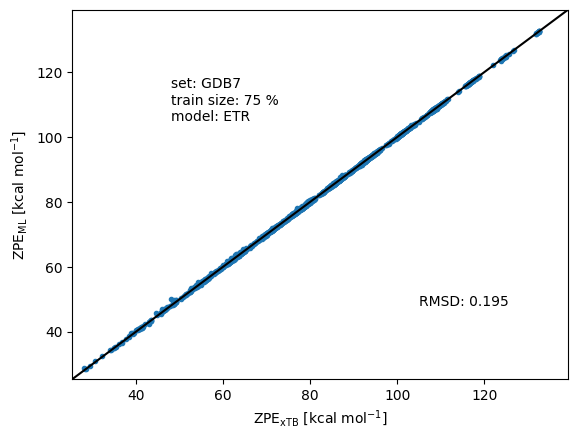

In [6]:

ZPE_pred =   a.ZPE_pred*627.509608
ZPE_true =   a.ZPE_true*627.509608

minv,maxv = np.min([np.min(ZPE_true),np.min(ZPE_pred)])*0.9,np.max([np.max(ZPE_true),np.max(ZPE_pred)])*1.05

plt.plot(ZPE_true,ZPE_pred,'.')
plt.plot([minv-np.abs(minv),2*maxv],[minv-np.abs(minv),2*maxv],'k')

RMSD = np.sqrt(np.sum((ZPE_true-ZPE_pred)**2)/len(ZPE_pred))

plt.xlabel(r'ZPE$_\mathrm{xTB}$ [kcal mol$^{-1}$]')
plt.ylabel(r'ZPE$_\mathrm{ML}$ [kcal mol$^{-1}$]')

plt.xlim([minv,maxv])
plt.ylim([minv,maxv])

plt.text((maxv-minv)*0.2+minv,(maxv-minv)*0.7+minv,f'set: GDB7 \ntrain size: 75 %\nmodel: ETR')
plt.text((maxv-minv)*0.7+minv,(maxv-minv)*0.2+minv,f'RMSD: {round(RMSD,3)}')
#plt.savefig('/Users/gfeldmann/Documents/hessian/gdb7/gdb7_pred_best/ZPVE.svg')

Text(6.7548635002369135, 1.5728181429248327, 'RMSD: 0.233')

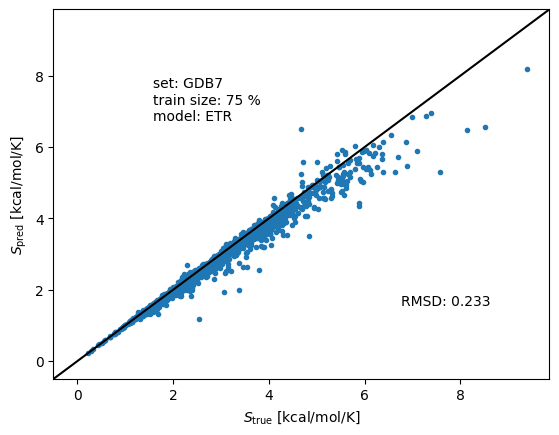

In [7]:
S_true =   np.log(a.Z_true)*8.3144*0.2390057
S_pred =   np.log(a.Z_pred)*8.3144*0.2390057

minv,maxv = np.min([np.min(S_true),np.min(S_pred)])*0.9,np.max([np.max(S_true),np.max(S_pred)])*1.05

plt.plot(S_true,S_pred,'.')
minv = -0.5
plt.plot([minv-np.abs(minv),2*maxv],[minv-np.abs(minv),2*maxv],'k')

RMSD = np.sqrt(np.sum((S_true-S_pred)**2)/len(S_pred))

plt.xlabel(r'$S_\mathrm{true}$ [kcal/mol/K]')
plt.ylabel(r'$S_\mathrm{pred}$ [kcal/mol/K]')

plt.xlim([minv,maxv])
plt.ylim([minv,maxv])

plt.text((maxv-minv)*0.2+minv,(maxv-minv)*0.7+minv,f'set: GDB7 \ntrain size: 75 %\nmodel: ETR')
plt.text((maxv-minv)*0.7+minv,(maxv-minv)*0.2+minv,f'RMSD: {round(RMSD,3)}')

#plt.savefig('/Users/gfeldmann/Documents/hessian/gdb7/gdb7_pred_best/Entropy.svg')